In [49]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch as t

from sometria.representation import Representation
from sometria.catalog import MotionViewSpec, build_motion_view
from sometria.dataset import MotionDataset
from sometria.masking import motion_aware_mask, patchify

WINDOW = 240      # 4 s @ 60 Hz
#PATCH = 8         # 133 ms, the same physical patch duration as MAMP's 4 frames @ 30 Hz
PATCH = 16         # 266 ms
MASK_RATIO = 0.80
TAU = 0.50

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
ROOT_DATA_DIR = "../data/processed"

representation = Representation.from_config("../config/human.yaml")
dataset = MotionDataset(
    root_folder=ROOT_DATA_DIR,
    representation=representation,
    normalization_path="stats/opensim_sincos_log_vel_acc_tau_v2/pretrain_v1_train_clean.pt",
    samples=build_motion_view(
        root=ROOT_DATA_DIR,
        spec=MotionViewSpec(
            split_set="babel_official",
            split="val",
            source_datasets=("AMASS",),
            min_frames=WINDOW + 60,   # short takes would be zero-padded, and padding scores as motionless
        )
    )
)

sample = dataset[18]
print(sample["sample_id"], sample["features"].shape)

AMASS:BMLrub/rub087/0025_kicking1_stageii.csv torch.Size([302, 43, 5])


In [50]:
VEL = representation.indices("vel")
ACC = representation.indices("acc")

window = sample["features"][60:WINDOW+60].unsqueeze(0)     # (1, T, D, C)
patches = patchify(window, PATCH)                     # (1, TP * D, PATCH, C)

B, L, _, _ = patches.shape
TP, D = WINDOW // PATCH, len(representation.dofs)

mask = motion_aware_mask(
    patches,
    score_channels=VEL,
    mask_ratio=MASK_RATIO,
    tau=TAU,
    generator=t.Generator().manual_seed(0),
)

print(f"{L} tokens ({TP} time patches x {D} dofs), token dim {PATCH * len(representation.channels)}")
print(f"context {mask.context.shape[1]}   targets {mask.targets.shape[1]}")

645 tokens (15 time patches x 43 dofs), token dim 80
context 129   targets 516


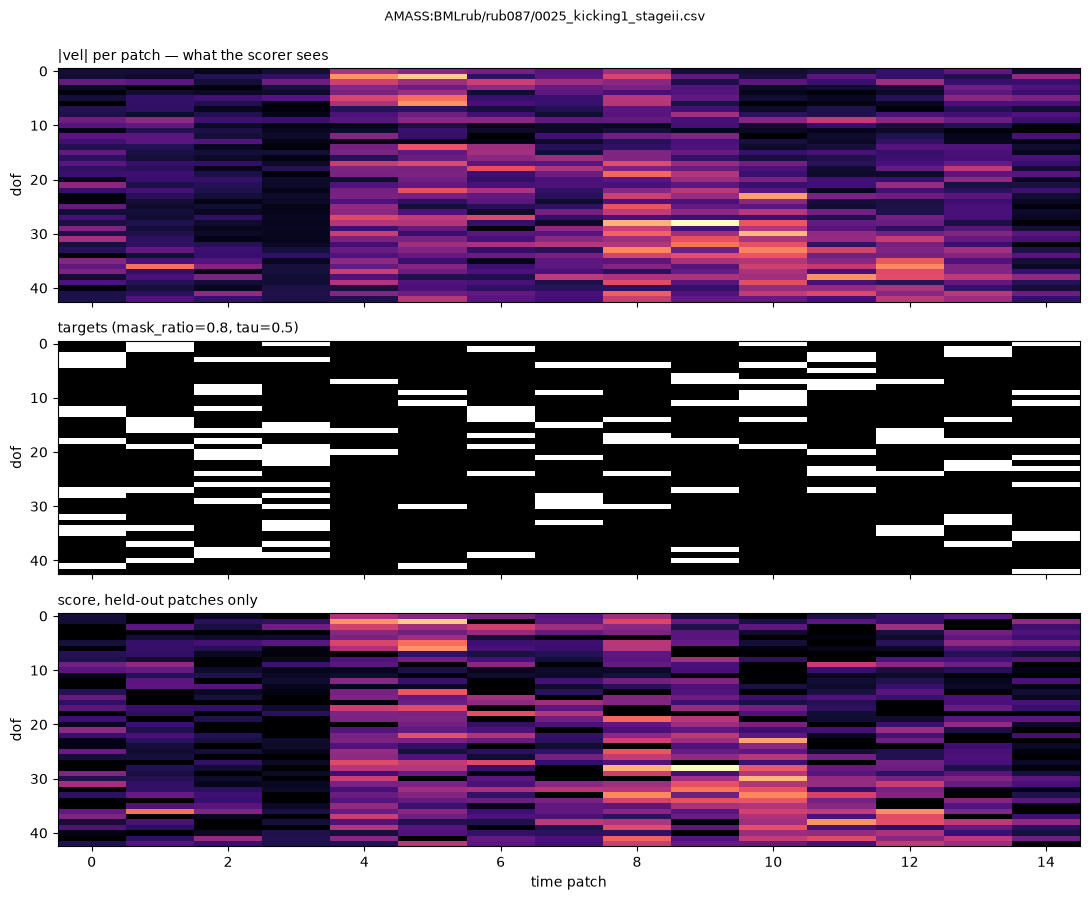

In [51]:
def as_grid(flat):
    """A flat token vector back onto the (time patch, dof) grid it came from."""
    return flat.reshape(TP, D).T                     # dofs on y, time on x


def target_grid(mask_indices):
    held = t.zeros(L)
    held[mask_indices.targets[0]] = 1.0
    return as_grid(held)


score = patches[..., VEL].abs().mean(dim=(-2, -1))[0]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, (data, title, cmap) in zip(axes, [
    (as_grid(score), "|vel| per patch — what the scorer sees", "magma"),
    (target_grid(mask), f"targets (mask_ratio={MASK_RATIO}, tau={TAU})", "gray_r"),
    (as_grid(score) * target_grid(mask), "score, held-out patches only", "magma"),
]):
    ax.imshow(data, aspect="auto", interpolation="nearest", cmap=cmap)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("dof")
axes[-1].set_xlabel("time patch")
fig.suptitle(sample["sample_id"], fontsize=9, y=0.995)
fig.tight_layout()

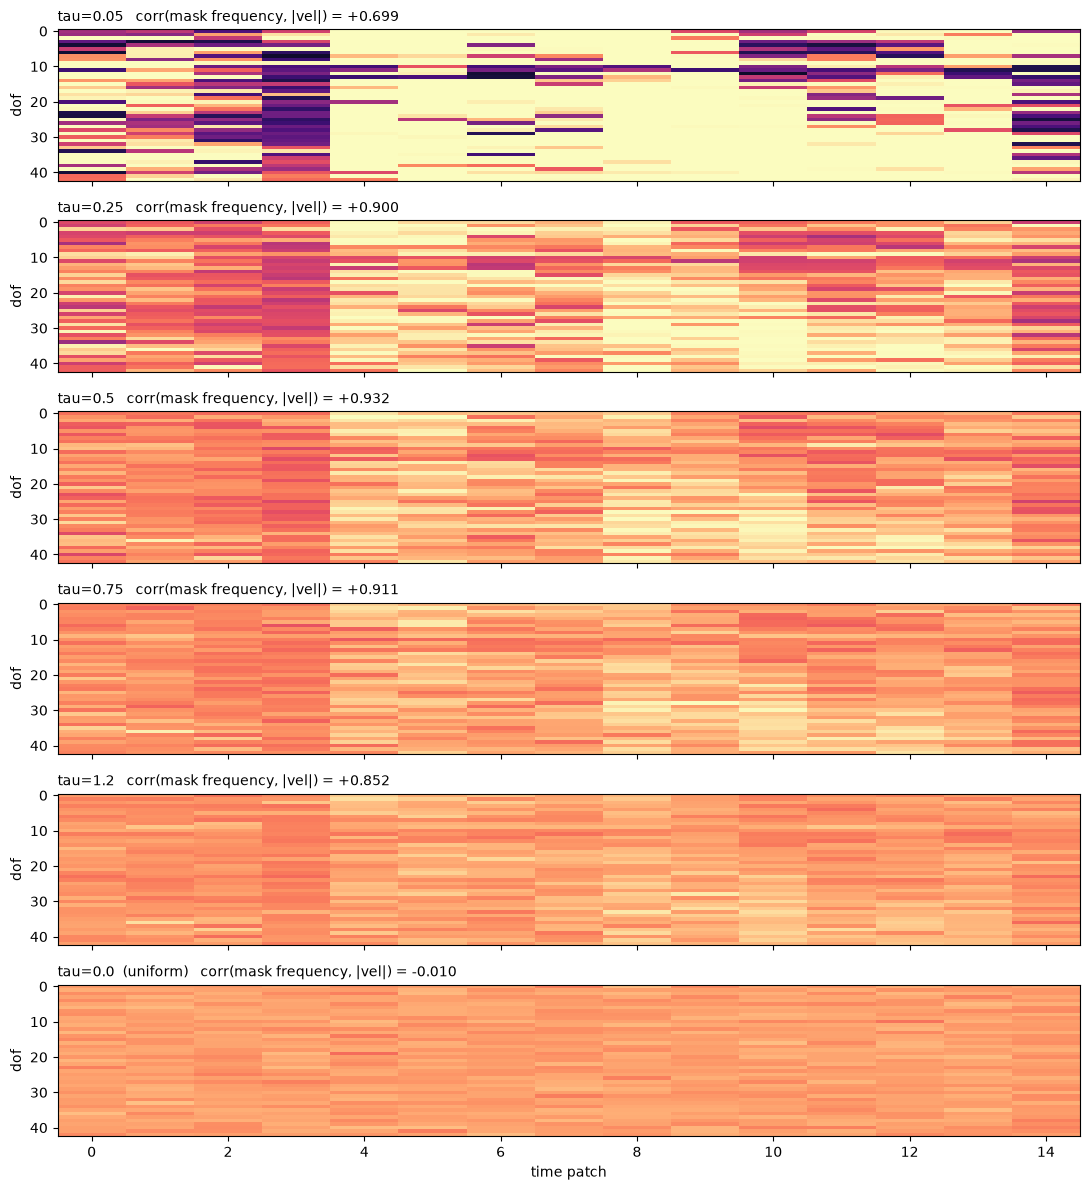

In [ ]:
# Sweep tau. Scores are max-normalized, so the logit spread is capped at 1/tau: small tau
# pins the mask to the loudest patches, large tau melts it into uniform static, and
# tau <= 0 skips scoring entirely. Averaged over draws so the trend is visible.
TAUS = [0.05, 0.25, 0.50, 0.75, 1.20, 

        0.0]
DRAWS = 200

g = t.Generator().manual_seed(0)
fig, axes = plt.subplots(len(TAUS), 1, figsize=(11, 2.0 * len(TAUS)), sharex=True)
for ax, tau in zip(axes, TAUS):
    freq = t.zeros(L)
    for _ in range(DRAWS):
        m = motion_aware_mask(patches, score_channels=VEL, mask_ratio=MASK_RATIO, tau=tau, generator=g)
        freq[m.targets[0]] += 1.0
    freq /= DRAWS

    corr = t.corrcoef(t.stack([freq, score]))[0, 1]
    ax.imshow(as_grid(freq), aspect="auto", interpolation="nearest", cmap="magma", vmin=0, vmax=1)
    ax.set_title(
        f"tau={tau}{'  (uniform)' if tau <= 0 else ''}   corr(mask frequency, |vel|) = {corr:+.3f}",
        loc="left", fontsize=10,
    )
    ax.set_ylabel("dof")
axes[-1].set_xlabel("time patch")
fig.tight_layout()